In [1]:
!pip list

Package                           Version
--------------------------------- --------------------
absl-py                           2.5.0
aiobotocore                       2.25.0
aiodns                            3.5.0
aiohappyeyeballs                  2.6.1
aiohttp                           3.13.2
aioitertools                      0.12.0
aiosignal                         1.4.0
alabaster                         0.7.16
altair                            5.5.0
anaconda-anon-usage               0.7.5
anaconda-auth                     0.12.3
anaconda-catalogs                 0.2.0
anaconda-cli-base                 0.7.0
anaconda-client                   1.14.0
anaconda-navigator                2.7.0
anaconda-project                  0.11.1
annotated-types                   0.6.0
anyio                             4.10.0
appdirs                           1.4.4
archspec                          0.2.5
argon2-cffi                       21.3.0
argon2-cffi-bindings              25.1.0
arrow        

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image,PIL.ImageFont,PIL.ImageDraw
import tensorflow as tf
import tensorflow_datasets as tfds
import os

In [3]:
im_width = 75
im_height = 75
use_normalised_coordinates = True 

In [4]:
def draw_bounding_boxes_on_image_array(image, boxes, color=[], thickness=1, display_str_list=()):
    image_pil = PIL.Image.fromarray(image)
    rgbimg = PIL.Image.new("RGBA", image_pil.size)
    rgbimg.paste(image_pil)

    draw_bounding_boxes_on_image(
        rgbimg,
        boxes,
        color=color,
        thickness=thickness,
        display_str_list=display_str_list
    )

    return np.array(rgbimg)


def draw_bounding_boxes_on_image(image, boxes, color=[], thickness=1, display_str_list=()):
    boxes_shape = boxes.shape

    if not boxes_shape:
        return

    if len(boxes_shape) != 2 or boxes_shape[1] != 4:
        raise ValueError("Input must be of size [N,4]")

    for i in range(boxes_shape[0]):
        draw_bounding_box_on_image(
            image,
            boxes[i,1],
            boxes[i,0],
            boxes[i,3],
            boxes[i,2],
            color[i],
            thickness,
            display_str_list[i]
        )


def draw_bounding_box_on_image(image, ymin, xmin, ymax, xmax,
                               color='red', thickness=1,
                               use_normalized_coordinates=True):

    draw = PIL.ImageDraw.Draw(image)
    im_width, im_height = image.size

    if use_normalized_coordinates:
        (left, right, top, bottom) = (
            xmin * im_width,
            xmax * im_width,
            ymin * im_height,
            ymax * im_height
        )
    else:
        (left, right, top, bottom) = (
            xmin,
            xmax,
            ymin,
            ymax
        )

    draw.line(
        [(left, top),
         (left, bottom),
         (right, bottom),
         (right, top),
         (left, top)],
        width=thickness,
        fill=color
    )

In [5]:
def dataset_to_numpy_util(training_dataset, validation_dataset, N):
    batch_train_ds = training_dataset.unbatch().batch(N)

    if tf.executing_eagerly():
        for validation_digits, (validation_labels, validation_bboxes) in validation_dataset:
            validation_digits = validation_digits.numpy()
            validation_labels = validation_labels.numpy()
            validation_bboxes = validation_bboxes.numpy()
            break

        for training_digits, (training_labels, training_bboxes) in training_dataset:
            training_digits = training_digits.numpy()
            training_labels = training_labels.numpy()
            training_bboxes = training_bboxes.numpy()
            break

    validation_labels = np.argmax(validation_labels, axis=1)
    training_labels = np.argmax(training_labels, axis=1)

    return (
        training_digits,
        training_labels,
        training_bboxes,
        validation_digits,
        validation_labels,
        validation_bboxes
    )

In [6]:
MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), "mpl-data/fonts/ttf")

def create_digits_from_local_fonts(n):
    font_labels = []

    img = PIL.Image.new('LA', (75*n, 75), color=(0,255))

    font1 = PIL.ImageFont.truetype(
        os.path.join(MATPLOTLIB_FONT_DIR, 'DejaVuSansMono-Oblique.ttf'), 25
    )

    font2 = PIL.ImageFont.truetype(
        os.path.join(MATPLOTLIB_FONT_DIR, 'STIXGeneral.ttf'), 25
    )

    d = PIL.ImageDraw.Draw(img)

    for i in range(n):
        font_labels.append(i % 10)
        d.text(
            ((7 + i * 75), 0 if i < 10 else -4),
            str(i % 10),
            fill=(255,255),
            font=font1 if i < 10 else font2
        )

    font_digits = np.array(img.getdata(), np.float32)[:,0] / 255.0

    font_digits = np.reshape(
        np.stack(
            np.split(
                np.reshape(font_digits, [75, 75*n]),
                n,
                axis=1
            ),
            axis=0
        ),
        [n, 75*75]
    )

    return font_digits, font_labels

In [7]:
def display_digits_with_boxes(digits, predictions, labels, pred_bboxes, bboxes, iou, title):

    n = 10

    indexes = np.random.choice(len(predictions), size=n)
    n_digits = digits[indexes]
    n_predictions = predictions[indexes]
    n_labels = labels[indexes]

    n_iou = []
    if len(iou) > 0:
        n_iou = iou[indexes]

    if len(pred_bboxes) > 0:
        n_pred_bboxes = pred_bboxes[indexes]

    if len(bboxes) > 0:
        n_bboxes = bboxes[indexes]

    n_digits = n_digits * 255.0
    n_digits = n_digits.reshape(n, 75, 75)

    fig = plt.figure(figsize=(20, 4))
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

    for i in range(10):
        ax = fig.add_subplot(1, 10, i + 1)

        bboxes_to_plot = []

        if len(pred_bboxes) > i:
            bboxes_to_plot.append(n_pred_bboxes[i])

        if len(bboxes) > i:
            bboxes_to_plot.append(n_bboxes[i])

        img_to_draw = draw_bounding_boxes_on_image_array(
            image=n_digits[i],
            boxes=np.asarray(bboxes_to_plot),
            color=['red', 'green'],
            display_str_list=["True", "Pred"]
        )

        plt.xlabel(n_predictions[i])
        plt.xticks([])
        plt.yticks([])

        if n_predictions[i] != n_labels[i]:
            ax.xaxis.label.set_color('red')

        plt.imshow(img_to_draw)

        if len(iou) > i:
            color = "black"

            if n_iou[i][0] < iou_threshold:
                color = "red"

            ax.text(
                0.2,
                -0.3,
                "iou: %s" % (n_iou[i][0]),
                color=color,
                transform=ax.transAxes
            )

In [8]:
def plot_metrics(metric_name,title):
    plt.title(title)
    plt.plot(history.history[metric_name],color='blue',label=metric_name)
    plt.plot(history.history['val_'+metric_name],color='green',label='val_'+metric_name)

In [9]:
strategy = tf.distribute.get_strategy()
strategy.num_replicas_in_sync

1

In [10]:
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

In [11]:
def read_image_tfds(image, label):

    xmin = tf.random.uniform((), 0, 48, dtype=tf.int32)

    ymin = tf.random.uniform((), 0, 48, dtype=tf.int32)

    image = tf.reshape(image, (28,28,1,))
  
    image = tf.image.pad_to_bounding_box(image, ymin, xmin, 75, 75)

    image = tf.cast(image, tf.float32) / 255.0

    xmin = tf.cast(xmin, tf.float32)

    ymin = tf.cast(ymin, tf.float32)

    xmax = (xmin + 28) / 75

    ymax = (ymin + 28) / 75

    xmin = xmin / 75

    ymax = ymin / 75

    return image,(tf.one_hot(label, 10), [xmin, ymin, xmax, ymax])

In [12]:
def get_training_dataset():
    with strategy.scope():
        dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
        dataset = dataset.shuffle(5000, reshuffle_each_iteration = True)
        dataset = dataset.repeat()
        dataset = dataset.batch(BATCH_SIZE, drop_remainder = True)
        dataset = dataset.prefetch(-1)    
    return dataset

In [13]:
def get_validation_dataset():
    with strategy.scope():
        dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
        dataset = dataset.batch(10000, drop_remainder = True)
        dataset = dataset.repeat()    
    return dataset

In [14]:
with strategy.scope():
    training_dataset = get_training_dataset()
    validation_dataset = get_validation_dataset()

In [15]:
(training_digits, training_labels, training_bboxes,
validation_digits, validation_labels, validation_bboxes) = dataset_to_numpy_util(training_dataset, validation_dataset, 10)

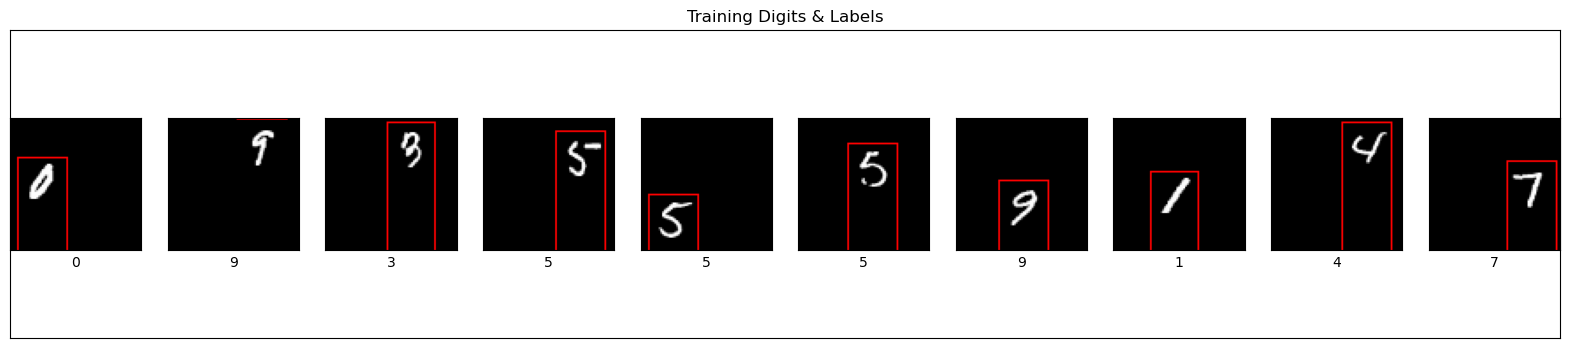

In [16]:
display_digits_with_boxes (training_digits, training_labels,
                           training_labels, np.array([]), training_bboxes,
                           np.array([]), "Training Digits & Labels")

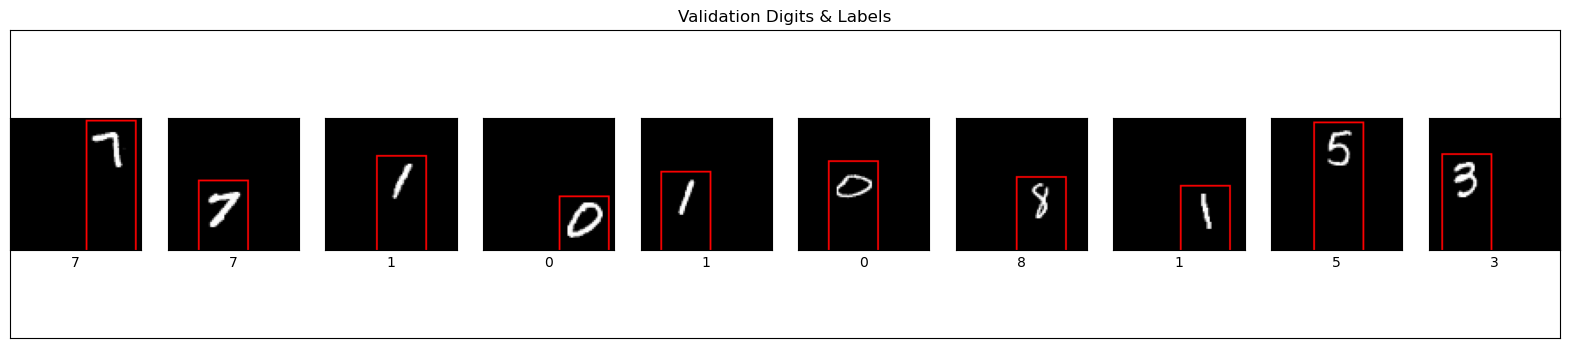

In [17]:
display_digits_with_boxes (validation_digits, validation_labels,
                           validation_labels, np.array([]), validation_bboxes,
                           np.array([]), "Validation Digits & Labels")

In [18]:
def feature_extractor(inputs):
    x = tf.keras.layers.Conv2D(16, activation = 'relu', kernel_size=3, input_shape=(75,75,1))(inputs)
    x = tf.keras.layers. AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(32, activation ='relu', kernel_size=3)(x)
    x = tf.keras.layers. AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(64, activation = 'relu', kernel_size=3)(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)
    return x

In [19]:
def dense_layers(inputs):
   x = tf.keras.layers. Flatten()(inputs)
   x = tf.keras.layers. Dense(128, activation='relu') (x)
   return x

In [20]:
def classifier(inputs):
    classification_output = tf.keras.layers. Dense(10, activation="softmax", name="classification")(inputs)
    return classification_output

In [21]:
def bounding_box_regression_output(inputs):
    bounding_box_regression_output = tf.keras.layers.Dense(4, name = "bounding_box")(inputs) 
    return bounding_box_regression_output

In [22]:
def final_model(inputs):
    feature_cnn = feature_extractor(inputs)
    dense_output = dense_layers(feature_cnn)
    
    classification_output = classifier(dense_output)
    bounding_box_output = bounding_box_regression_output(dense_output)

    model = tf.keras.Model(inputs = inputs, outputs = [classification_output,bounding_box_output])
    return model

In [23]:
def define_and_compile_model(inputs):
    model = final_model(inputs)

    model.compile(optimizer = 'adam',loss= {'classification' : 'categorical_crossentropy',
                                            'bounding_box':'mse'},
                  metrics = {'classification' : 'accuracy',
                             'bounding_box' : 'mse'})

    return model

In [24]:
with strategy.scope():
    inputs = tf.keras.layers.Input(shape=(75,75,1))
    model= define_and_compile_model(inputs)

model.summary()

C:\Users\spand\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 75, 75, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 73, 73, 16)        │             160 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d             │ (None, 36, 36, 16)        │               0 │ conv2d[0][0]               │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 34, 34, 32)        │           4,640 │ average_pooling2d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_1           │ (None, 17, 17, 32)        │               0 │ conv2d_1[0][0]             │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 15, 15, 64)        │          18,496 │ average_pooling2d_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_2           │ (None, 7, 7, 64)          │               0 │ conv2d_2[0][0]             │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 3136)              │               0 │ average_pooling2d_2[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         401,536 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classification (Dense)        │ (None, 10)                │           1,290 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bounding_box (Dense)          │ (None, 4)                 │             516 │ dense[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 20
steps_per_epoch = 60000

history = model.fit(training_dataset,steps_per_epoch=steps_per_epoch,
                    validation_data=validation_dataset,validation_steps=1,epochs=EPOCHS)

loss,classification_loss,bounding_box_loss,classification_acc,bounding_box_mse= model.evaluate(validation_dataset,steps = 1)
print("\n-------------------------------\n")
print("Validation Accuracy:", classification_acc)
print("\n-------------------------------\n")

Epoch 1/20


C:\Users\spand\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 5473/60000 ━━━━━━━━━━━━━━━━━━━━ 19:25:42 1s/step - bounding_box_loss: 1.1851 - bounding_box_mse: 1.1851 - classification_accuracy: 0.5067 - classification_loss: 1.3959 - loss: 2.5810

In [ ]:
plot_metrics("bounding_box_mse","Bounding Box MSE")

In [ ]:
plot_metrics("classification_accuracy","classification Accuracy")

In [ ]:
plot_metrics("classification_loss","classification Loss")

In [ ]:
def intersection_over_union(pred_box, true_box):
    xmin_pred, ymin_pred, xmax_pred, ymax_pred = np.split(pred_box, 4, axis = 1)
    xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis = 1)

    smoothing_factor = 1e-10

    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)

    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

    overlap_area = np.maximum((xmax_overlap - xmin_overlap), 0) * np.maximum((ymax_overlap - ymin_overlap), 0)
    union_area = (pred_box_area + true_box_area) - overlap_area

    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)

    return iou

In [ ]:
prediction = model.predict(validation_digits, batch_size = 64)

predicted_labels = np.argmax(prediction[0], axis = 1)

prediction_bboxes = prediction[1]

In [ ]:
iou = intersection_over_union(prediction_bboxes, validation_bboxes)

iou_threshold = 0.6

display_digits_with_boxes(validation_digits, predicted_labels, validation_labels,
                          prediction_bboxes, validation_bboxes, iou, "True and Pred values")